In [1]:
import pandas as pd; print('xarray')
import xarray as xr; print('numpy')
import numpy as np; print('restantes')
import matplotlib.pyplot as plt
from glob import glob as gb
from matplotlib.gridspec import GridSpec
from scipy.stats import pearsonr
from scipy.stats import linregress

xarray
numpy
restantes


In [2]:
def p1_boxplot(files):
    fall='../input_csv/all_experimentos.csv' #files[0] #
    ftopo='../input_csv/topo_all_experimentos.csv'#files[3] #
    var='alt'
    t1=pd.read_csv(fall)
    a1=pd.read_csv(ftopo)
    f1=pd.concat([t1,a1],axis=1)
    f2=f1.T.drop_duplicates().T
    f31=f2[sorted([e for e in f2.columns if 'alt' in e])]
    f32=f31[f31.columns[:5]]
    f7=p1(f32,var)    
    for i in range(len(f7.columns)):
        f7[f7.columns[i]]=pd.to_numeric(f7[f7.columns[i]], errors='coerce')
        f7.columns=['exp0','exp1','exp2','exp3']
    return f7

In [3]:
def adi_boxplot(ax,bop):
    ax.set_title('Topography') #MOD30_SOM
    #bop.columns=['GMTs\nMOD30\nSOM','GMTns\nMOD30\nSOM','SRTs\nMOD30\nSOM','SRTns\nMOD30\nSOM']
    bop.columns=['GMT\ns','GMT\nns','SRT\ns','SRT\nns']
    ax.axhline(y = 0, color = 'r', linestyle = '-',zorder=2,linewidth=1,alpha=.7)
    #ax.set_ylabel('[m]', labelpad=-10,rotation=0,va='top')
    #pos_label(ax,'[m]',-.125,.96,rota=0)
    pos_label(ax,'[m]',-.075,.96,rota=0)
    bop.boxplot(ax=ax,zorder=3,rot=0)
    ax.set_title('a)',loc='left')

In [17]:
def crea_mod_obs(cort):
    files=gb('../input_csv/*%s.csv'%(cort))
    print(len(files))
    for i,file in enumerate(files):        
        df=pd.read_csv(file)
        #print(df)
        if i==0: df2=df.copy()
        else: df2=pd.concat([df2,df],axis=1, join="inner")
    df3=df2.T.drop_duplicates()
    df4=df3.T
    m1=df4[df4['tipo']==1]
    #print(m1.corr()[['pr','t2m']][6:7])
    o1=(df4[df4['tipo']==0]).drop_duplicates('lat')
    m1=m1.reset_index(drop=True)
    o1=o1.reset_index(drop=True)
    return m1,o1

In [5]:
def p1(f4,var):
    for i in range(4):
        data=f4[f4.columns[i+1]].values-f4[var].values
        if i==0: df=pd.DataFrame(data=data,columns=['dif_%s_e%s'%(var,i)])
        else: df['dif_%s_e%s'%(var,i)]=data
    return df

In [6]:
def adi_plot_b1(ax,axn,corte,tipo,letra):
    ax.set_title(letra,loc='left') #letra='a)'
    ax.set_title(tipo) # tipo='NL'
    ax.margins(x=0.004) 
    axn.grid(linestyle=':',linewidth=.7,alpha=.9)
    ax.grid(axis='x', linestyle=':',linewidth=.6,alpha=.9)
    #ax.set_ylabel('[m]',loc='center')#, color='b')    
    #pos_label(ax,'[m]',-.025,.96,rota=0)
    pos_label(ax,'[m]',-.017,.96,rota=0)
    if '1' in corte:
        ax.set_ylim([3750,4950]) #[3780,4160]   
        #x1,y1,x2,y2=330,3980,336,3980        
        x1,y1,x2,y2=330,7,336,7       
    else:   
        ax.set_ylim([3750,4950]) #[3800,4950]
        x1,y1,x2,y2=502,7,512,7
        #x1,y1,x2,y2=502,4410,512,4410
    axn.set_ylim([0.1,12])
    #axn.text(x1,8,'[mm/mon]',color='darkgreen',rotation=90,va='center')#,ha='center')
    #axn.text(x2,8,'[°C]',color='darkred',rotation=90,va='center')#,ha='center')    
    pos_label(ax,'[°C]',1.02,.96,rota=0,colo='darkred')
    pos_label(ax,r'[$\frac{mm}{mon}$]',1.022,.04,rota=0,colo='darkgreen')#

In [7]:
def plot_t1(cort,mod,ax1):
    files=gb('../input_csv/%s*.txt'%(cort))
    for file in files[:]:
        f=pd.read_csv(file,sep='\t')
    datos_caja=[]
    for var,plab in zip(['pr','t2m'],['Precipitation','Temperature']):
        if var=='pr': co1='g'; ec='darkgreen';co='w';co2='w'
        else: co1='r'; ec='darkred';co='w';co2='w'
        x1,y1=mod['topo'],mod[var]
        x2,y2=f['alt'],f[var]
        ax1.scatter(x1,y1,c=co2,edgecolor=ec,alpha=.8,s=15,label='GMTns_EVA_SIE %s'%plab)
        ax1.scatter(x2,y2,c=co1,edgecolor='.2',linewidth=.71)
        mod_trend=trend_1(ax1,x1,y1,'k')
        obs_trend=trend_1(ax1,x2,y2,'b')
        datos_caja.append(mod_trend)
        datos_caja.append(obs_trend)        
    ax1.set_title(cort)
    ax1.set_xlim([3800,4980])
    ax1.set_ylim([2,14])
    return datos_caja

In [8]:
def trend_1(ax1,x0,y,colo):
    x=x0
    lwid=1.4; alph=.9      
    cor, p_value = pearsonr(x, y)
    cor2=cor**2    
    coefficients = np.polyfit(x, y, 1)  # Ajuste polinomial de grado 1 (línea recta)
    trendline = np.polyval(coefficients, x)
    coefficients = np.polyfit(x, y, 1) 
    trendline = np.poly1d(coefficients)   
    txt1=f'r: {cor:.2f}' #r
    if p_value<.05: txt2='%s sig'%txt1        
    else: txt2='%s non-sig'%txt1
    ax1.plot(x, trendline(x), color=colo,linestyle='-',linewidth=lwid,alpha=alph)      
    return txt2

In [11]:
def adi_plot_t1(ax,tipo,txt,letra):
    ax.set_title(letra,loc='left') # letra='e)'
    ax.set_title(tipo) # tipo='FFL'
    #ax.set_xlabel('[m]',loc='center')#, color='b') 
    #textstr = '\n'.join(('prec_mod_%s'%txt[0],'prec_obs_%s'%txt[1],'t2m_mod_%s'%txt[2],'t2m_obs_%s'%txt[3]))
    textstr = '\n'.join(('prc %s'%txt[0],'t2m %s'%txt[2]))
    props = dict(boxstyle='round', facecolor='w', alpha=0,ec='none')
    ax.text(0.45, 0.83, textstr, transform=ax.transAxes,fontsize=7,verticalalignment='bottom', bbox=props,c='k')
    textstr = '\n'.join(('prc %s'%txt[1],'t2m %s'%txt[3]))
    props = dict(boxstyle='round', facecolor='w', alpha=0,ec='none')
    ax.text(0.45, 0.68, textstr, transform=ax.transAxes,fontsize=7,verticalalignment='bottom', bbox=props,c='b')
    pos_label(ax,'[m]',.96,-.09,rota=0)
    pos_label(ax,'[°C]',-.08,.96,rota=0,colo='darkred')
    pos_label(ax,r'[$\frac{mm}{mon}$]',-.1,.04,rota=0,colo='darkgreen')

In [12]:
def pos_label(ax,lab,x,y,rota=0,colo='k',tus='no'): #x de 0 a 1, y de 0 a 1
    label_x = x  # Coordenada x
    label_y = y  # Coordenada y    
    tu=ax.text(label_x, label_y, lab, transform=ax.transAxes, va='center', ha='center', rotation=rota,c=colo)
    if not 'no' in tus: tu.set_bbox(dict(facecolor='y', alpha=0.7, edgecolor='y',boxstyle='round,pad=.01'))

In [13]:
def plot_b1(f6,ob,tipo,cut,ax2,legend):    
    ax2.set_facecolor('0.98')
    ax2.plot(f6.acum_distancia,f6.topo,c='0.3',linewidth=.5,linestyle=':',zorder=1)    
    ax2.fill_between(f6.acum_distancia,f6.topo, color='0.7', label='GMTns_EVA_SIE Altitude',alpha=1)
    ax2.scatter(ob.acum_distancia,ob['topo'],label='Observed Altitude',marker='x',c='.2',s=50,zorder=8)
    ax1 = ax2.twinx()    
    tlab='Temperature'#
    plab='Precipitation'# [mm/mon]    
    #ax1.grid(linestyle=':',linewidth=.7,alpha=.9)
    #ax2.grid(axis='x', linestyle=':',linewidth=.6,alpha=.9)
    #ax2.set_ylabel('[m]',loc='center')#, color='b')    
    if 'line' in tipo:
        ax1.plot(f6.acum_distancia,f6['pr'],label='GMTns_EVA_SIE %s'%plab,c='darkgreen',lw=1.7,zorder=2,alpha=1)
        ax1.plot(f6.acum_distancia,f6['t2m'],label='GMTns_EVA_SIE %s'%tlab,c='firebrick',lw=1.7,zorder=1,alpha=1)
        ax1.scatter(ob.acum_distancia,ob['pr'],label='Observed %s'%plab,marker='o',c='darkgreen',s=70,ec='.2',zorder=2,lw=.71,alpha=1)
        ax1.scatter(ob.acum_distancia,ob['t2m'],label='Observed %s'%tlab,marker='o',c='firebrick',s=70,ec='.2',zorder=2,lw=.71,alpha=1)
        
    else:
        ax1.scatter(f6.acum_distancia,f6['pr'],label='%s'%tlab,marker='o',c='w',s=40,edgecolor='teal',zorder=5)
        ax1.scatter(f6.acum_distancia,f6['t2m'],label='%s'%plab,marker='o',c='w',s=40,edgecolor='firebrick',zorder=5)
        
    np1=4.2-1.12
    np2=4.2-.18
    if 'on' in legend: 
        ax2.legend(loc='upper left', bbox_to_anchor=(0.752,np1),frameon=False)
        ax1.legend(loc='upper left', bbox_to_anchor=(0.750,np2),frameon=False)
    ax1.set_ylim([2,14])
    #ax3 = ax2.twinx()     
    return ax1

2
2
3
2
2


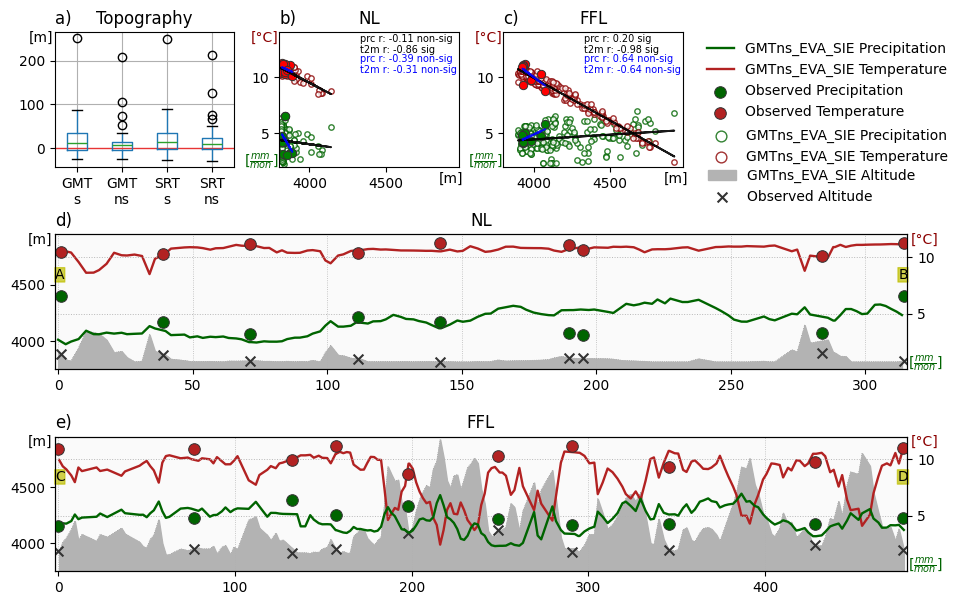

In [18]:
fig = plt.figure(constrained_layout=False,figsize=(11,7))
gs = GridSpec(3,4, figure=fig,hspace=.5,wspace=.25)
#
ax = fig.add_subplot(gs[1, :])   
cort='corte1'
mod,obs=crea_mod_obs(cort)
ax3=plot_b1(mod,obs,'line',cort,ax,'no')
adi_plot_b1(ax,ax3,cort,'NL','d)')
pos_label(ax,'A',0.006,.7,rota=0,colo='k',tus='si')
pos_label(ax,'B',0.995,.7,rota=0,colo='k',tus='si')
#
ax = fig.add_subplot(gs[2, :])  
cort='corte2'
mod,obs=crea_mod_obs(cort)
ax3=plot_b1(mod,obs,'line',cort,ax,'on')
adi_plot_b1(ax,ax3,cort,'FFL','e)')
pos_label(ax,'C',0.006,.7,rota=0,colo='k',tus='si')
pos_label(ax,'D',0.995,.7,rota=0,colo='k',tus='si')
#
ax = fig.add_subplot(gs[0, 0:1])  
fis=sorted(gb('../input_csv/*_all_*csv'))
print(len(fis))
bp=p1_boxplot(fis)
adi_boxplot(ax,bp)
#
ax = fig.add_subplot(gs[0, 1:2]) 
cort='corte1'
mod,obs=crea_mod_obs(cort)
text3=plot_t1(cort,mod,ax)
adi_plot_t1(ax,'NL',text3,'b)')
#
ax = fig.add_subplot(gs[0, 2:3])    
cort='corte2'
mo,ob=crea_mod_obs(cort)
text3=plot_t1(cort,mo,ax)
adi_plot_t1(ax,'FFL',text3,'c)')
#
legend = ax.legend(markerscale=2,loc='lower left', bbox_to_anchor=(1.065,-.07),fontsize=10)
# Set a white frame for the legend
legend.get_frame().set_facecolor('none')
legend.get_frame().set_edgecolor('none')
#plt.savefig('salidas/topo_20240207_v1.png',dpi=400, bbox_inches='tight')